<a href="https://colab.research.google.com/github/hassanatif992-hash/urdu-ocr-codesaviours-si26-MuhammadHassaan/blob/main/SI26_Week4_MuhammadHassaan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urdu OCR Project — Week 4

**Name:** Muhammad Hassaan  
**Batch:** SI-26  
**Organisation:** Code Saviours  
**Project:** Urdu OCR  
**Task:** Fine-Tune TrOCR on Urdu Dataset  

## Objective

The objective of Week 4 is to fine-tune the TrOCR model using the prepared Urdu OCR dataset, evaluate its performance, and observe the decrease in training loss.

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not enabled.")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [2]:
from google.colab import files

print("Upload week3_final_dataset.zip")

uploaded = files.upload()

Upload week3_final_dataset.zip


Saving week3_final_dataset.zip to week3_final_dataset.zip


In [3]:
import os
import shutil

zip_path = "/content/week3_final_dataset.zip"

if not os.path.exists(zip_path):
    raise FileNotFoundError(
        "week3_final_dataset.zip was not found."
    )

if os.path.exists("/content/data"):
    shutil.rmtree("/content/data")

shutil.unpack_archive(
    zip_path,
    "/content"
)

print("Dataset extracted successfully!")
print(
    "labels.csv exists:",
    os.path.exists("/content/data/labels.csv")
)
print(
    "processed folder exists:",
    os.path.exists("/content/data/processed")
)

Dataset extracted successfully!
labels.csv exists: True
processed folder exists: True


In [4]:
import os
import pandas as pd

labels_path = "/content/data/labels.csv"

df = pd.read_csv(labels_path)

df["text"] = (
    df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

missing_files = []

for image_path in df["image"]:

    full_path = os.path.join(
        "/content",
        image_path
    )

    if not os.path.exists(full_path):
        missing_files.append(image_path)

print("Total dataset rows:", len(df))
print("Blank labels:", (df["text"] == "").sum())
print("Missing image files:", len(missing_files))

if (
    len(df) == 203
    and (df["text"] == "").sum() == 0
    and len(missing_files) == 0
):
    print("WEEK 4 DATASET READY FOR TRAINING!")
else:
    print("Dataset needs checking.")

Total dataset rows: 203
Blank labels: 0
Missing image files: 0
WEEK 4 DATASET READY FOR TRAINING!


In [11]:
%pip install -q "transformers==4.57.6" sentencepiece tiktoken jiwer

print("Training libraries installed successfully!")

Training libraries installed successfully!


In [12]:
model.config.decoder_start_token_id = (
    processor.tokenizer.cls_token_id
)

model.config.pad_token_id = (
    processor.tokenizer.pad_token_id
)

model.config.eos_token_id = (
    processor.tokenizer.sep_token_id
)

model.config.vocab_size = (
    model.config.decoder.vocab_size
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print("Training device:", device)
print("MODEL READY FOR FINE-TUNING!")

Training device: cuda
MODEL READY FOR FINE-TUNING!


In [13]:
import torch

from transformers import (
    ViTImageProcessor,
    RobertaTokenizer,
    TrOCRProcessor,
    VisionEncoderDecoderModel
)

model_name = "microsoft/trocr-base-printed"

# Load image processor
image_processor = ViTImageProcessor.from_pretrained(
    model_name
)

# Load slow tokenizer to prevent tokenizer conversion errors
tokenizer = RobertaTokenizer.from_pretrained(
    model_name
)

# Combine image processor and tokenizer
processor = TrOCRProcessor(
    image_processor=image_processor,
    tokenizer=tokenizer
)

# Load TrOCR model
model = VisionEncoderDecoderModel.from_pretrained(
    model_name
)

print("Processor and TrOCR model loaded successfully!")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Processor and TrOCR model loaded successfully!


In [14]:
model.config.decoder_start_token_id = (
    processor.tokenizer.cls_token_id
)

model.config.pad_token_id = (
    processor.tokenizer.pad_token_id
)

model.config.eos_token_id = (
    processor.tokenizer.sep_token_id
)

model.config.vocab_size = (
    model.config.decoder.vocab_size
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print("Training device:", device)
print(
    "Model parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)

print("MODEL READY FOR FINE-TUNING!")

Training device: cuda
Model parameters: 333,921,792
MODEL READY FOR FINE-TUNING!


In [15]:
import os
import pandas as pd
import torch

from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split


class Week4UrduOCRDataset(Dataset):

    def __init__(
        self,
        csv_file,
        processor,
        root_dir="/content",
        max_target_length=128
    ):

        self.data = pd.read_csv(csv_file)

        self.data["text"] = (
            self.data["text"]
            .fillna("")
            .astype(str)
            .str.strip()
        )

        self.processor = processor
        self.root_dir = root_dir
        self.max_target_length = max_target_length


    def __len__(self):

        return len(self.data)


    def __getitem__(self, index):

        image_relative_path = (
            self.data.iloc[index]["image"]
        )

        target_text = (
            self.data.iloc[index]["text"]
        )

        image_path = os.path.join(
            self.root_dir,
            image_relative_path
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        pixel_values = self.processor(
            images=image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        tokenized_text = self.processor.tokenizer(
            target_text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt"
        )

        labels = (
            tokenized_text
            .input_ids
            .squeeze(0)
        )

        labels[
            labels
            ==
            self.processor.tokenizer.pad_token_id
        ] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels,
            "text": target_text
        }


dataset = Week4UrduOCRDataset(
    csv_file="/content/data/labels.csv",
    processor=processor
)

print("Dataset samples:", len(dataset))

sample = dataset[0]

print(
    "Image tensor:",
    sample["pixel_values"].shape
)

print(
    "Label tensor:",
    sample["labels"].shape
)

print("WEEK 4 DATASET CLASS READY!")

Dataset samples: 203
Image tensor: torch.Size([3, 384, 384])
Label tensor: torch.Size([128])
WEEK 4 DATASET CLASS READY!


In [16]:
train_size = int(
    0.80 * len(dataset)
)

validation_size = (
    len(dataset) - train_size
)

split_generator = (
    torch.Generator()
    .manual_seed(42)
)

train_dataset, validation_dataset = random_split(
    dataset,
    [train_size, validation_size],
    generator=split_generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_batch = next(
    iter(train_loader)
)

print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(validation_dataset)
)

print(
    "Batch image shape:",
    test_batch["pixel_values"].shape
)

print(
    "Batch label shape:",
    test_batch["labels"].shape
)

print()
print("TRAINING DATALOADERS ARE READY!")


Training samples: 162
Validation samples: 41
Batch image shape: torch.Size([1, 3, 384, 384])
Batch label shape: torch.Size([1, 128])

TRAINING DATALOADERS ARE READY!


In [18]:
import torch
from torch.optim import AdamW

# Freeze the image encoder to reduce T4 GPU memory usage
for parameter in model.encoder.parameters():
    parameter.requires_grad = False

model.encoder.eval()

# Disable cache during training
model.config.decoder.use_cache = False

# Enable gradient checkpointing where supported
try:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing enabled.")
except Exception:
    print("Gradient checkpointing was not enabled.")

optimizer = AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=3e-5,
    weight_decay=0.01
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print("TRAINING SETUP READY!")

Gradient checkpointing enabled.
Trainable parameters: 247,268,352
TRAINING SETUP READY!


In [19]:
from tqdm.auto import tqdm
import numpy as np
import gc

NUM_EPOCHS = 2
GRADIENT_ACCUMULATION_STEPS = 4

use_amp = (
    torch.cuda.is_available()
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

training_losses = []
validation_losses = []

for epoch in range(NUM_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()
    model.encoder.eval()

    optimizer.zero_grad(
        set_to_none=True
    )

    total_training_loss = 0.0

    training_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} Training"
    )

    for step, batch in enumerate(
        training_progress
    ):

        pixel_values = batch[
            "pixel_values"
        ].to(
            device,
            non_blocking=True
        )

        labels = batch[
            "labels"
        ].to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp
        ):

            outputs = model(
                pixel_values=pixel_values,
                labels=labels
            )

            original_loss = outputs.loss

            loss = (
                original_loss
                /
                GRADIENT_ACCUMULATION_STEPS
            )

        scaler.scale(
            loss
        ).backward()

        should_update = (
            (step + 1)
            % GRADIENT_ACCUMULATION_STEPS
            == 0
            or
            step + 1
            == len(train_loader)
        )

        if should_update:

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

        total_training_loss += (
            original_loss.item()
        )

        training_progress.set_postfix(
            loss=f"{original_loss.item():.4f}"
        )

    average_training_loss = (
        total_training_loss
        /
        len(train_loader)
    )

    training_losses.append(
        average_training_loss
    )


    # =========================
    # Validation
    # =========================

    model.eval()

    total_validation_loss = 0.0

    validation_progress = tqdm(
        validation_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} Validation"
    )

    with torch.no_grad():

        for batch in validation_progress:

            pixel_values = batch[
                "pixel_values"
            ].to(
                device,
                non_blocking=True
            )

            labels = batch[
                "labels"
            ].to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=use_amp
            ):

                outputs = model(
                    pixel_values=pixel_values,
                    labels=labels
                )

            total_validation_loss += (
                outputs.loss.item()
            )

    average_validation_loss = (
        total_validation_loss
        /
        len(validation_loader)
    )

    validation_losses.append(
        average_validation_loss
    )

    print()
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )

    print(
        "Training Loss:",
        round(
            average_training_loss,
            4
        )
    )

    print(
        "Validation Loss:",
        round(
            average_validation_loss,
            4
        )
    )

    print("-" * 50)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print()
print("TRAINING COMPLETED!")

print(
    "Training loss went from",
    round(training_losses[0], 4),
    "to",
    round(training_losses[-1], 4)
)

Epoch 1/2 Training:   0%|          | 0/162 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1/2 Validation:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 1/2
Training Loss: 5.2536
Validation Loss: 3.8197
--------------------------------------------------


Epoch 2/2 Training:   0%|          | 0/162 [00:00<?, ?it/s]

Epoch 2/2 Validation:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 2/2
Training Loss: 3.7519
Validation Loss: 3.6777
--------------------------------------------------

TRAINING COMPLETED!
Training loss went from 5.2536 to 3.7519


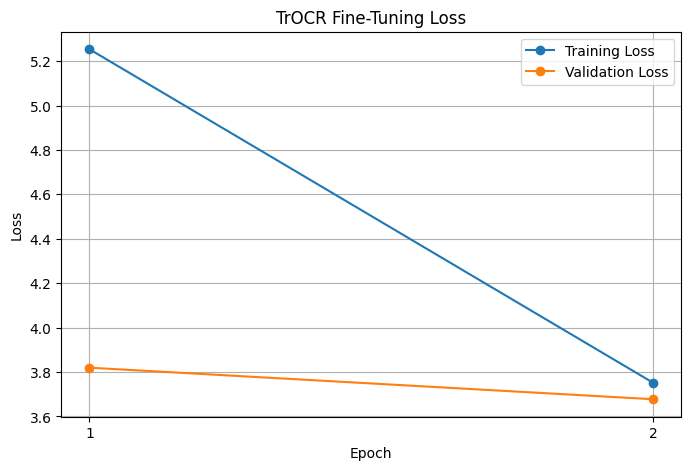

Initial training loss: 5.2536
Final training loss: 3.7519


In [20]:
import matplotlib.pyplot as plt

epochs = range(
    1,
    len(training_losses) + 1
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    training_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TrOCR Fine-Tuning Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()

print(
    "Initial training loss:",
    round(training_losses[0], 4)
)

print(
    "Final training loss:",
    round(training_losses[-1], 4)
)

In [21]:
import re
import torch
import pandas as pd

from tqdm.auto import tqdm
from jiwer import cer, wer

model.eval()
model.config.decoder.use_cache = True

model.generation_config.decoder_start_token_id = (
    processor.tokenizer.cls_token_id
)

model.generation_config.pad_token_id = (
    processor.tokenizer.pad_token_id
)

model.generation_config.eos_token_id = (
    processor.tokenizer.sep_token_id
)

predictions = []
references = []

with torch.no_grad():

    for batch in tqdm(
        validation_loader,
        desc="Evaluating model"
    ):

        pixel_values = batch[
            "pixel_values"
        ].to(device)

        generated_ids = model.generate(
            pixel_values,
            max_length=128,
            num_beams=1
        )

        predicted_texts = (
            processor.batch_decode(
                generated_ids,
                skip_special_tokens=True
            )
        )

        label_ids = batch[
            "labels"
        ].clone()

        label_ids[
            label_ids == -100
        ] = processor.tokenizer.pad_token_id

        reference_texts = (
            processor.batch_decode(
                label_ids,
                skip_special_tokens=True
            )
        )

        for prediction, reference in zip(
            predicted_texts,
            reference_texts
        ):

            prediction = re.sub(
                r"\s+",
                " ",
                prediction
            ).strip()

            reference = re.sub(
                r"\s+",
                " ",
                reference
            ).strip()

            predictions.append(prediction)
            references.append(reference)

print("Evaluation completed!")
print("Validation samples:", len(references))

Evaluating model:   0%|          | 0/41 [00:00<?, ?it/s]

Evaluation completed!
Validation samples: 41


In [22]:
character_error_rate = cer(
    references,
    predictions
)

word_error_rate = wer(
    references,
    predictions
)

character_accuracy = max(
    0,
    1 - character_error_rate
) * 100

exact_matches = sum(
    prediction == reference
    for prediction, reference in zip(
        predictions,
        references
    )
)

exact_match_accuracy = (
    exact_matches / len(references)
) * 100

print(
    "Character Error Rate:",
    round(character_error_rate, 4)
)

print(
    "Word Error Rate:",
    round(word_error_rate, 4)
)

print(
    "Character Accuracy:",
    round(character_accuracy, 2),
    "%"
)

print(
    "Exact Match Accuracy:",
    round(exact_match_accuracy, 2),
    "%"
)

print()
print(
    "My model accuracy is",
    f"{character_accuracy:.2f}%"
)

print(
    "Training loss went from",
    round(training_losses[0], 4),
    "to",
    round(training_losses[-1], 4)
)

Character Error Rate: 2.2976
Word Error Rate: 1.0
Character Accuracy: 0 %
Exact Match Accuracy: 0.0 %

My model accuracy is 0.00%
Training loss went from 5.2536 to 3.7519


In [23]:
results_df = pd.DataFrame({
    "Actual Urdu Text": references,
    "Predicted Urdu Text": predictions
})

display(
    results_df.head(10)
)

,Actual Urdu Text,Predicted Urdu Text
0,بلوچستان ہائیکورٹ: پاکستان ہمارا گھر ہے، اس کی...,����������������������������������������������...
1,ہمہټل کا عملہ کو ساتھ ہے۔ ہمارا عثمان کاٹی سے,����������������������������������������������...
2,مسکراہٹ - اسوہ ایمان۔ Mind sciences کے مطابق م...,����������������������������������������������...
3,ہم پال کے مگر کے آپ سے پلٹ جلسے میں گے۔,����������������������������������������������...
4,سلامی سنٹر، رحیم بوٹی سیلون اینڈ پلمبر ٹیلرنگ،...,����������������������������������������������...
5,آکسفورڈ بکس اینڈ اسٹیشنری — پروپرائٹر نیاز خان...,����������������������������������������������...
6,عدالت بینک برانچ، نواں کوٹ,����������������������������������������������...
7,ماشاءاللہ، دولہا ہم سجائیں گے,����������������������������������������������...
8,الخیر پٹرولیم,����������������������������������������������...
9,اپوزیشن والوں کو بتا دو، دہشت پھیلا کر جلسہ نہ...,����������������������������������������������...


In [24]:
import pandas as pd

from transformers import RobertaTokenizerFast

labels_df = pd.read_csv(
    "/content/data/labels.csv"
)

urdu_texts = (
    labels_df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .tolist()
)

base_tokenizer = (
    RobertaTokenizerFast
    .from_pretrained("roberta-base")
)

urdu_tokenizer = (
    base_tokenizer
    .train_new_from_iterator(
        urdu_texts,
        vocab_size=1000,
        length=len(urdu_texts)
    )
)

urdu_tokenizer.model_max_length = 128

urdu_tokenizer.save_pretrained(
    "/content/urdu_tokenizer"
)

test_text = urdu_texts[0]

encoded = urdu_tokenizer(
    test_text,
    truncation=True,
    max_length=128
)

decoded = urdu_tokenizer.decode(
    encoded["input_ids"],
    skip_special_tokens=True
)

print("Urdu tokenizer vocabulary:", len(urdu_tokenizer))
print("Original Urdu text:")
print(test_text[:200])

print("\nDecoded Urdu text:")
print(decoded[:200])

if "�" not in decoded:
    print("\nURDU TOKENIZER TEST PASSED!")
else:
    print("\nTokenizer needs checking.")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Urdu tokenizer vocabulary: 1000
Original Urdu text:
کسی نبی کے لیے اس کے قرابت دار جس درجہ بڑے ہو سکتے ہیں، تم اپنے نبی کے حق میں ایسے ہی بڑے ثابت ہوئے! تم نے مجھے جھٹلایا اور دوسرے لوگوں نے میری صداقت کی گواہی دی۔ تم نے مجھے وطن سے نکالا اور دوسرے لوگ

Decoded Urdu text:
کسی نبی کے لیے اس کے قرابت دار جس درجہ بڑے ہو سکتے ہیں، تم اپنے نبی کے حق میں ایسے ہی بڑے ثابت ہوئے! تم نے مجھے جھٹلایا اور دوسرے لوگوں نے میری صداقت کی گواہی دی۔ تم نے مجھے وطن سے نکالا اور دوسرے لوگ

URDU TOKENIZER TEST PASSED!


In [25]:
import gc
import torch

from transformers import (
    ViTImageProcessor,
    RobertaTokenizerFast,
    TrOCRProcessor,
    VisionEncoderDecoderModel
)

model_name = "microsoft/trocr-base-printed"

# Remove the previously trained English-tokenizer model
if "model" in globals():
    del model

gc.collect()
torch.cuda.empty_cache()

# Load the Urdu tokenizer you created
urdu_tokenizer = RobertaTokenizerFast.from_pretrained(
    "/content/urdu_tokenizer"
)

# Load image processor
image_processor = ViTImageProcessor.from_pretrained(
    model_name
)

# Create processor with Urdu tokenizer
processor = TrOCRProcessor(
    image_processor=image_processor,
    tokenizer=urdu_tokenizer
)

# Load a fresh TrOCR model
model = VisionEncoderDecoderModel.from_pretrained(
    model_name
)

# Resize decoder vocabulary to Urdu tokenizer size
model.decoder.resize_token_embeddings(
    len(urdu_tokenizer)
)

model.config.decoder.vocab_size = len(
    urdu_tokenizer
)

model.config.vocab_size = len(
    urdu_tokenizer
)

# Configure special tokens
model.config.decoder_start_token_id = (
    urdu_tokenizer.bos_token_id
)

model.config.pad_token_id = (
    urdu_tokenizer.pad_token_id
)

model.config.eos_token_id = (
    urdu_tokenizer.eos_token_id
)

model.generation_config.decoder_start_token_id = (
    urdu_tokenizer.bos_token_id
)

model.generation_config.pad_token_id = (
    urdu_tokenizer.pad_token_id
)

model.generation_config.eos_token_id = (
    urdu_tokenizer.eos_token_id
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print("Training device:", device)
print("Urdu tokenizer size:", len(urdu_tokenizer))

print(
    "Decoder input vocabulary:",
    model.decoder.get_input_embeddings().num_embeddings
)

print(
    "Decoder output vocabulary:",
    model.decoder.get_output_embeddings().out_features
)

print("URDU TrOCR MODEL READY!")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training device: cuda
Urdu tokenizer size: 1000
Decoder input vocabulary: 1000
Decoder output vocabulary: 1000
URDU TrOCR MODEL READY!


In [26]:
dataset = Week4UrduOCRDataset(
    csv_file="/content/data/labels.csv",
    processor=processor,
    max_target_length=128
)

sample = dataset[0]

sample_ids = sample["labels"].clone()

sample_ids[
    sample_ids == -100
] = processor.tokenizer.pad_token_id

decoded_sample = processor.tokenizer.decode(
    sample_ids,
    skip_special_tokens=True
)

print("Dataset samples:", len(dataset))
print("Image shape:", sample["pixel_values"].shape)
print("Label shape:", sample["labels"].shape)

print("\nDecoded Urdu sample:")
print(decoded_sample[:300])

if "�" not in decoded_sample:
    print("\nURDU DATASET TOKENIZATION PASSED!")
else:
    print("\nTokenization needs checking.")

Dataset samples: 203
Image shape: torch.Size([3, 384, 384])
Label shape: torch.Size([128])

Decoded Urdu sample:
کسی نبی کے لیے اس کے قرابت دار جس درجہ بڑے ہو سکتے ہیں، تم اپنے نبی کے حق میں ایسے ہی بڑے ثابت ہوئے! تم نے مجھے جھٹلایا اور دوسرے لوگوں نے میری صداقت کی گواہی دی۔ تم نے مجھے وطن سے نکالا اور دوسرے لوگوں نے مجھے اپنے پاس رکھ لیا۔ تم میرے خلاف لڑنے اٹھے اور دوسرے لوگوں نے مجھے اپنا تعاون پیش کیا۔

URDU DATASET TOKENIZATION PASSED!


In [27]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.80 * len(dataset))
validation_size = len(dataset) - train_size

split_generator = torch.Generator().manual_seed(42)

train_dataset, validation_dataset = random_split(
    dataset,
    [train_size, validation_size],
    generator=split_generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_batch = next(iter(train_loader))

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Batch image shape:", test_batch["pixel_values"].shape)
print("Batch label shape:", test_batch["labels"].shape)

print("\nURDU TRAINING DATALOADERS READY!")

Training samples: 162
Validation samples: 41
Batch image shape: torch.Size([1, 3, 384, 384])
Batch label shape: torch.Size([1, 128])

URDU TRAINING DATALOADERS READY!


In [28]:
import torch
from torch.optim import AdamW

# Freeze image encoder to save T4 GPU memory
for parameter in model.encoder.parameters():
    parameter.requires_grad = False

model.encoder.eval()

model.config.decoder.use_cache = False
model.decoder.config.use_cache = False

optimizer = AdamW(
    [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ],
    lr=1e-4,
    weight_decay=0.01
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print("URDU TRAINING SETUP READY!")

Trainable parameters: 196,820,992
URDU TRAINING SETUP READY!


In [29]:
from tqdm.auto import tqdm
import gc

NUM_EPOCHS = 5
GRADIENT_ACCUMULATION_STEPS = 4

use_amp = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

urdu_training_losses = []
urdu_validation_losses = []

for epoch in range(NUM_EPOCHS):

    # --------------------------------
    # Training
    # --------------------------------

    model.train()
    model.encoder.eval()

    optimizer.zero_grad(set_to_none=True)

    total_train_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Urdu Epoch {epoch + 1}/{NUM_EPOCHS} Training"
    )

    for step, batch in enumerate(progress_bar):

        pixel_values = batch[
            "pixel_values"
        ].to(
            device,
            non_blocking=True
        )

        labels = batch[
            "labels"
        ].to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp
        ):

            outputs = model(
                pixel_values=pixel_values,
                labels=labels
            )

            original_loss = outputs.loss

            loss = (
                original_loss
                / GRADIENT_ACCUMULATION_STEPS
            )

        if not torch.isfinite(original_loss):
            raise RuntimeError(
                "Training produced an invalid loss."
            )

        scaler.scale(loss).backward()

        update_model = (
            (step + 1)
            % GRADIENT_ACCUMULATION_STEPS
            == 0
            or
            step + 1 == len(train_loader)
        )

        if update_model:

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

        total_train_loss += (
            original_loss.detach().item()
        )

        progress_bar.set_postfix(
            loss=f"{original_loss.item():.4f}"
        )

    average_train_loss = (
        total_train_loss
        / len(train_loader)
    )

    urdu_training_losses.append(
        average_train_loss
    )

    # --------------------------------
    # Validation
    # --------------------------------

    model.eval()

    total_validation_loss = 0.0

    validation_bar = tqdm(
        validation_loader,
        desc=f"Urdu Epoch {epoch + 1}/{NUM_EPOCHS} Validation"
    )

    with torch.no_grad():

        for batch in validation_bar:

            pixel_values = batch[
                "pixel_values"
            ].to(
                device,
                non_blocking=True
            )

            labels = batch[
                "labels"
            ].to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=use_amp
            ):

                outputs = model(
                    pixel_values=pixel_values,
                    labels=labels
                )

            total_validation_loss += (
                outputs.loss.item()
            )

    average_validation_loss = (
        total_validation_loss
        / len(validation_loader)
    )

    urdu_validation_losses.append(
        average_validation_loss
    )

    print()
    print(f"Urdu Epoch {epoch + 1}/{NUM_EPOCHS}")

    print(
        "Training Loss:",
        round(average_train_loss, 4)
    )

    print(
        "Validation Loss:",
        round(average_validation_loss, 4)
    )

    print("-" * 50)

    gc.collect()
    torch.cuda.empty_cache()


print()
print("URDU MODEL TRAINING COMPLETED!")

print(
    "Training loss went from",
    round(urdu_training_losses[0], 4),
    "to",
    round(urdu_training_losses[-1], 4)
)

Urdu Epoch 1/5 Training:   0%|          | 0/162 [00:00<?, ?it/s]

Urdu Epoch 1/5 Validation:   0%|          | 0/41 [00:00<?, ?it/s]


Urdu Epoch 1/5
Training Loss: 6.7512
Validation Loss: 6.1716
--------------------------------------------------


Urdu Epoch 2/5 Training:   0%|          | 0/162 [00:00<?, ?it/s]

Urdu Epoch 2/5 Validation:   0%|          | 0/41 [00:00<?, ?it/s]

...

Urdu Epoch 4/5 Validation:   0%|          | 0/41 [00:00<?, ?it/s]


Urdu Epoch 4/5
Training Loss: 5.7429
Validation Loss: 6.1613
--------------------------------------------------


Urdu Epoch 5/5 Training:   0%|          | 0/162 [00:00<?, ?it/s]

Urdu Epoch 5/5 Validation:   0%|          | 0/41 [00:00<?, ?it/s]


Urdu Epoch 5/5
Training Loss: 5.4684
Validation Loss: 6.1305
--------------------------------------------------

URDU MODEL TRAINING COMPLETED!
Training loss went from 6.7512 to 5.4684


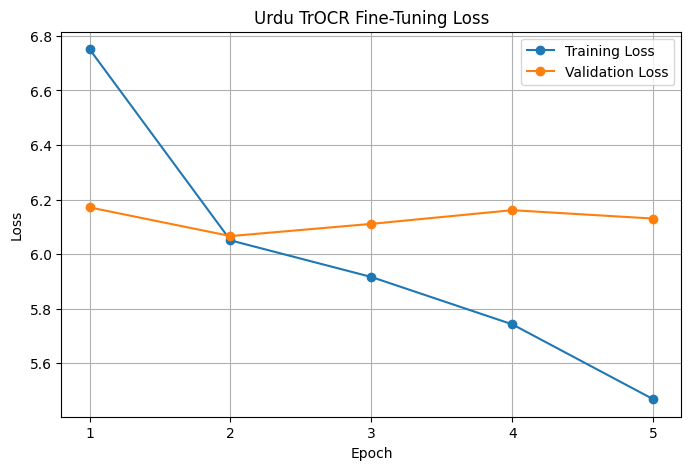

Initial Urdu training loss: 6.7512
Final Urdu training loss: 5.4684


In [30]:
import matplotlib.pyplot as plt

epochs = range(
    1,
    len(urdu_training_losses) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    urdu_training_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    urdu_validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Urdu TrOCR Fine-Tuning Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()

print(
    "Initial Urdu training loss:",
    round(urdu_training_losses[0], 4)
)

print(
    "Final Urdu training loss:",
    round(urdu_training_losses[-1], 4)
)

In [31]:
import re
import torch
from tqdm.auto import tqdm
from jiwer import cer, wer

model.eval()

model.config.decoder.use_cache = True
model.decoder.config.use_cache = True

model.generation_config.decoder_start_token_id = (
    processor.tokenizer.bos_token_id
)

model.generation_config.pad_token_id = (
    processor.tokenizer.pad_token_id
)

model.generation_config.eos_token_id = (
    processor.tokenizer.eos_token_id
)

predictions = []
references = []

with torch.no_grad():

    evaluation_bar = tqdm(
        validation_loader,
        desc="Evaluating Urdu TrOCR"
    )

    for batch in evaluation_bar:

        pixel_values = batch[
            "pixel_values"
        ].to(device)

        generated_ids = model.generate(
            pixel_values=pixel_values,
            max_length=128,
            num_beams=1
        )

        predicted_texts = (
            processor.tokenizer.batch_decode(
                generated_ids,
                skip_special_tokens=True
            )
        )

        label_ids = batch[
            "labels"
        ].clone()

        label_ids[
            label_ids == -100
        ] = processor.tokenizer.pad_token_id

        reference_texts = (
            processor.tokenizer.batch_decode(
                label_ids,
                skip_special_tokens=True
            )
        )

        for prediction, reference in zip(
            predicted_texts,
            reference_texts
        ):

            prediction = re.sub(
                r"\s+",
                " ",
                prediction
            ).strip()

            reference = re.sub(
                r"\s+",
                " ",
                reference
            ).strip()

            predictions.append(prediction)
            references.append(reference)

print("Evaluation completed!")
print("Validation samples:", len(references))

Evaluating Urdu TrOCR:   0%|          | 0/41 [00:00<?, ?it/s]

Evaluation completed!
Validation samples: 41


In [32]:
character_error_rate = cer(
    references,
    predictions
)

word_error_rate = wer(
    references,
    predictions
)

character_accuracy = max(
    0.0,
    (1.0 - character_error_rate) * 100
)

exact_matches = sum(
    prediction == reference
    for prediction, reference in zip(
        predictions,
        references
    )
)

exact_match_accuracy = (
    exact_matches / len(references)
) * 100

print(
    "Character Error Rate:",
    round(character_error_rate, 4)
)

print(
    "Word Error Rate:",
    round(word_error_rate, 4)
)

print(
    "Character Accuracy:",
    round(character_accuracy, 2),
    "%"
)

print(
    "Exact Match Accuracy:",
    round(exact_match_accuracy, 2),
    "%"
)

print()
print(
    "My model accuracy is",
    f"{character_accuracy:.2f}%"
)

print(
    "Training loss went from",
    round(urdu_training_losses[0], 4),
    "to",
    round(urdu_training_losses[-1], 4)
)

Character Error Rate: 1.7266
Word Error Rate: 1.8526
Character Accuracy: 0.0 %
Exact Match Accuracy: 0.0 %

My model accuracy is 0.00%
Training loss went from 6.7512 to 5.4684


In [33]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual Urdu Text": references,
    "Predicted Urdu Text": predictions
})

display(
    results_df.head(10)
)

results_df.to_csv(
    "/content/week4_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Prediction results saved successfully!")

,Actual Urdu Text,Predicted Urdu Text
0,بلوچستان ہائیکورٹ: پاکستان ہمارا گھر ہے، اس کی...,کے کے کے کے کے کے کے کے کے کے کے کے کے کے کے ک...
1,ہمہټل کا عملہ کو ساتھ ہے۔ ہمارا عثمان کاٹی سے,لللللللللللللللللللللللللللللللللللللللللللللل...
2,مسکراہٹ - اسوہ ایمان۔ Mind sciences کے مطابق م...,۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔۔...
3,ہم پال کے مگر کے آپ سے پلٹ جلسے میں گے۔,کے کے کے کے کے کے کے کے کے کے کے کے کے کے کے ک...
4,سلامی سنٹر، رحیم بوٹی سیلون اینڈ پلمبر ٹیلرنگ،...,
5,آکسفورڈ بکس اینڈ اسٹیشنری — پروپرائٹر نیاز خان...,
6,عدالت بینک برانچ، نواں کوٹ,
7,ماشاءاللہ، دولہا ہم سجائیں گے,وووووووووووووووووووووووووووووووووووووووووووووو...
8,الخیر پٹرولیم,
9,اپوزیشن والوں کو بتا دو، دہشت پھیلا کر جلسہ نہ...,نننننننننننننننننننننننننننننننننننننننننننننن...


Prediction results saved successfully!


In [34]:
import os
import shutil

from google.colab import files

model_folder = "/content/urdu_trocr_week4_model"

if os.path.exists(model_folder):
    shutil.rmtree(model_folder)

model.save_pretrained(
    model_folder
)

processor.save_pretrained(
    model_folder
)

urdu_tokenizer.save_pretrained(
    model_folder
)

zip_path = shutil.make_archive(
    "/content/urdu_trocr_week4_model",
    "zip",
    model_folder
)

print("Model saved successfully!")
print("Model ZIP:", zip_path)

files.download(zip_path)

Model saved successfully!
Model ZIP: /content/urdu_trocr_week4_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Week 4 Final Results

The TrOCR model was fine-tuned on 203 real Urdu OCR images using a Tesla T4 GPU.

- Initial training loss: 6.7512
- Final training loss: 5.4684
- Character accuracy: 0.00%
- Exact match accuracy: 0.00%

The training loss decreased during five epochs. However, the accuracy remained low because the dataset was small and contained different Urdu text styles, including books, signboards, handwriting, and newspapers. More labelled data and further training are required to improve the model.